In [ ]:
import pandas as pd 
df = pd.read_csv("mutant_moneyball.csv") 
df_tidy = df.melt(id_vars=['Member'], 
                  value_vars=['TotalValue60s_heritage', 'TotalValue70s_heritage', 'TotalValue80s_heritage', 
                              'TotalValue90s_heritage', 'TotalValue60s_ebay', 'TotalValue70s_ebay','TotalValue80s_ebay',
                              'TotalValue90s_ebay',	'TotalValue60s_wiz', 'TotalValue70s_wiz', 'TotalValue80s_wiz',
                              'TotalValue90s_wiz', 'TotalValue60s_oStreet', 'TotalValue70s_oStreet', 'TotalValue80s_oStreet',
                              'TotalValue90s_oStreet'], 
                 var_name='Evaluator', 
                 value_name='Valuation') # melts table to align with Tidy Data Principles
df_tidy[['Decade', 'Source']] = df_tidy['Evaluator'].str.split("_", expand=True) # splits Evaluator column into Source (of evaluation) and Decade
df_tidy['Decade'] = df_tidy['Decade'].str.replace("TotalValue", '', regex=False) # removes TotalValue from decade and evaluator columnts
df_tidy['Valuation'] = (
    df_tidy['Valuation']
    .astype(str)
    .replace('[\$,\s]', '', regex=True)) # removes dollar sign to allow for proper visualization without causing valuations to be read as strings
df_tidy['Valuation'] = pd.to_numeric(df_tidy['Valuation'], errors='coerce') # adjusts values to prevent null values when making evaluations uniform
new_sources = {
    "heritage" : "Heritage",
    "ebay" : "Ebay",
    "wiz" : "Wiz",
    "ostreet" : "O Street"} # renames sources of evaluation to more readable form 
members_renamed = {
    'warrenWorthington' : 'Warren Worthington',
    'hankMcCoy' : 'Hank McCoy',
    'scottSummers' : 'Scott Summers',
    'bobbyDrake' : 'Bobby Drake',
    'jeanGrey' : 'Jean Grey',
    'alexSummers' : 'Alex Summers',
    'lornaDane' : 'Lorna Dane',
    'ororoMunroe' : 'Ororo Munroe',
    'kurtWagner' : 'Kurt Wagner',
    'loganHowlett' : 'Logan Howlett',
    'peterRasputin' : 'Peter Rasputin',
    'seanCassidy' : 'Sean Cassidy',
    'shiroYoshida' : 'Shiro Yoshida',
    'johnProudstar' : 'John Proudstar',
    'kittyPryde' : 'Kitty Pryde',
    'annaMarieLeBeau' : 'Anna Marie LeBeau',
    'rachelSummers' : 'Rachel Summers',
    'ericMagnus' : 'Eric Magnus',
    'alisonBlaire' : 'Alison Blaire',
    'longshot' : 'Longshot',
    'jonathanSilvercloud': 'Jonathon Silvercloud',
    'remyLeBeau' : 'Remy LeBeau',
    'jubilationLee' : 'Jubiliation Lee',
    'lucasBishop' : 'Lucas Bishop',
    'betsyBraddock' : 'Betsy Braddock',
    'charlesXavier' : 'Charles Xavier'} # change names from canalCase to be more readable
final_df_tidy = df_tidy.drop(columns=['Evaluator']) # drops now-redundant evaluator column
final_df_tidy["Source"] = final_df_tidy["Source"].str.lower().replace(new_sources) # replaces new sources to clean the dataset 
final_df_tidy["Member"] = final_df_tidy["Member"].replace(members_renamed) # adds the renamed members to the cleaned dataset
print(final_df_tidy) # displays cleaned dataset

### DATA CLEANING ### 
In this first step, I took actions to make the dataset as readable and clean as possible. Since both platform and decade were captured in the same column, I employed Tidy Data Principles to split up these values, making both individuals observations in the cleaned data set. I then dropped the original, now redundant column. I also renamed both the sources of data and the X-Men within the data itself to increase readability through dictionaries that reassigned values. In addition, I expanded my skillset and added code that made sure that no dollar signs or commas were included to increase readability. Finally, I printed the new clean dataset that followed Tidy Data principles with each cell containing a single value, each member of the X-Men forming their own row, and each variable forming a single column. 

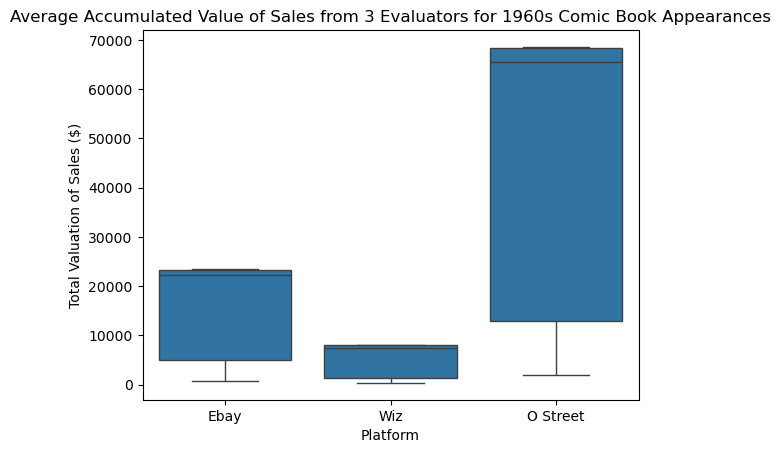

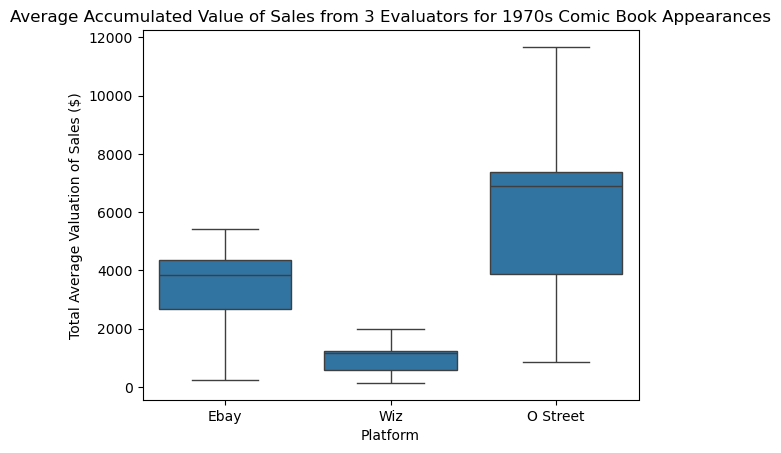

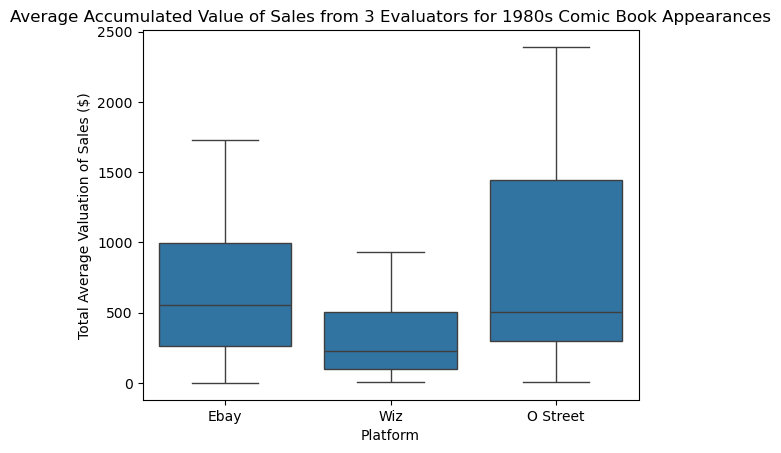

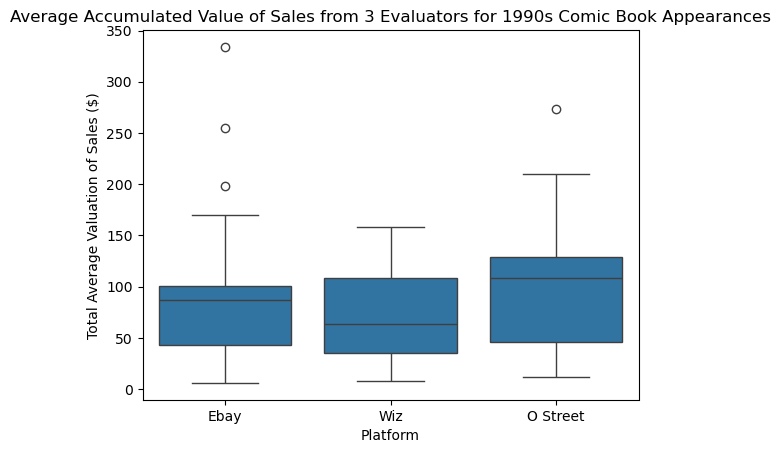

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
# These 4 graphs are grouped together to show change over time as denoted by the Y axis 
fdt = final_df_tidy 
plt.title("Average Accumulated Value of Sales from 3 Evaluators for 1960s Comic Book Appearances") # Uses the three evaluators with metrics in similar magnitudes; all based on average accumulated valueof sales from certain decades 
sixties_df = fdt[(fdt['Decade']=='60s') & ~(fdt['Source']=='Heritage')] # Heritage uses highest sale, not total accumulated value
sns.boxplot(
    data=sixties_df,
    x='Source',
    y='Valuation') # uses boxplot to show averages, quartiles, standard deviations, and outliers; avoids creation of false negative values of violin plots 
plt.xlabel("Platform") # axes renamed 
plt.ylabel('Total Valuation of Sales ($)')
plt.show()

plt.title("Average Accumulated Value of Sales from 3 Evaluators for 1970s Comic Book Appearances") # same as above graph 
seventies_df = fdt[(fdt['Decade']=='70s') & ~(fdt['Source']=='Heritage')]
sns.boxplot(
    data=seventies_df,
    x='Source',
    y='Valuation')
plt.xlabel("Platform")
plt.ylabel("Total Average Valuation of Sales ($)")
plt.show()

plt.title("Average Accumulated Value of Sales from 3 Evaluators for 1980s Comic Book Appearances")
eighties_df = fdt[(fdt['Decade']=='80s') & ~(fdt['Source']=='Heritage')]
sns.boxplot(
    data=eighties_df,
    x='Source',
    y='Valuation')
plt.xlabel("Platform")
plt.ylabel("Total Average Valuation of Sales ($)")
plt.show()

fdt = final_df_tidy
plt.title("Average Accumulated Value of Sales from 3 Evaluators for 1990s Comic Book Appearances")
nineties_df = fdt[(fdt['Decade']=='90s') & ~(fdt['Source']=='Heritage')] 
sns.boxplot(
    data=nineties_df,
    x='Source',
    y='Valuation')
plt.xlabel("Platform")
plt.ylabel("Total Average Valuation of Sales ($)")
plt.show()

### 1st Four Charts ### 
These first four charts are critical because 3/4 platforms track accumulated sales for comics from a certain decade. Over time, sales go down, showing the value of older comic book appearances. Using an average of all X-Men in a decade for each evaluator, one can see the average total value sold on each platform across all characters. Together, all four graphs provide a complete picture as to the total sales across X-men on each platform. 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heritage_df = fdt[fdt['Source'] == 'Heritage'].copy() # allows for modifications without affecting original data

plt.figure(figsize=(12, 6)) # changes sidze to accomodate many data points 
sns.scatterplot(
    data=heritage_df,
    x='Member',       
    y='Valuation',
    hue='Decade') # color-coded scatterplot used show change in individual value over time; Heritage values are individual highs for each decade
# More X-Men are present over time because most characters were added later 
plt.title('Heritage Value of X-Men Members Across Decades')
plt.xlabel("X-Men Members")
plt.ylabel("Heritage Valuation ($)")
plt.xticks(rotation=45, ha='right') # drastically increases readability thorugh adjusted orientation of x-axis labels 
plt.grid(axis='y', linestyle='--', alpha=0.6) # increases readability of graph through better spacing  
plt.tight_layout()
plt.show()

### Heritage Chart ### 

Heritage's value are much higher. This is because Heritage tracks the highest individual sale of an appearnce for each member of the X-Men. Based on this difference, I created a separate scatterplot color-coded scatterplot. As more characters are added, more data points appear. Values decline over time, as a 1960s appearance of Professor X is much more valuable than a 1990s appearance of Kitty Pryde. This graph optimizes readability while providing a stronger understanding of scale through a collectibles auction house. 

Text(0, 0.5, 'Average Valuation Price of X-Men Members')

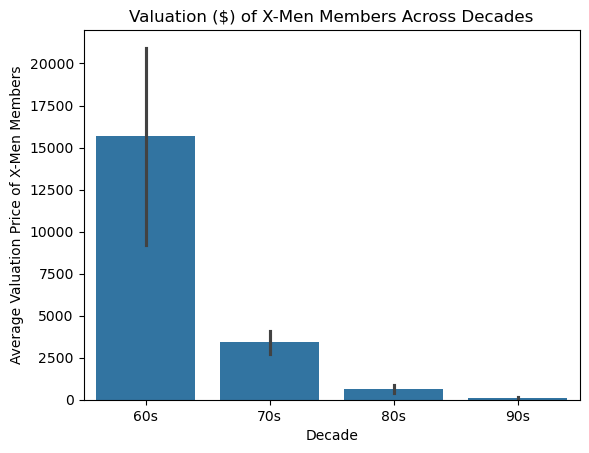

In [30]:
ebay_df = final_df_tidy[final_df_tidy['Source']=='Ebay'] # Shows Evaluation of prices over time 
sns.barplot(
    data=ebay_df,
    x='Decade',
    y='Valuation')
plt.title('Valuation ($) of X-Men Members Across Decades')
plt.xlabel('Decade')
plt.ylabel('Average Valuation Price of X-Men Members')

In [ ]:
ebay_df = final_df_tidy[final_df_tidy['Source']=='Wiz'] # Shows Evaluation of prices over time 
sns.barplot(
    data=ebay_df,
    x='Decade',
    y='Valuation')
plt.title('Valuation ($) of X-Men Members Across Decades')
plt.xlabel('Decade')
plt.ylabel('Average Valuation Price of X-Men Members')

In [ ]:
o_street_df=final_df_tidy[final_df_tidy['Source']=='O Street']
sns.barplot(
    data=o_street_df,
    x='Decade',
    y='Valuation')
plt.title('Valuation ($) of X-Men Members Across Decades')
plt.xlabel('Decade')
plt.ylabel('Average Valuation Price of X-Men Members')

### Last 3 Graphs ###
In an inverse of the previous chart, the individuals platforms are made a subset and the decades are categorized on the x-axis, allowing for an understanding of average valuation across time. This shows the decline of average accumulated value over time from each source. This allows for isolation to see differences in each of the three accumulation platforms used in the dataset. 

In [ ]:
final_df_tidy['Valuation'] = final_df_tidy['Valuation'].replace('[\$,]', '', regex=True)
final_df_tidy['Valuation'] = pd.to_numeric(final_df_tidy['Valuation'], errors='coerce')

summary_table1 = final_df_tidy.pivot_table(
    index = 'Source', 
    columns = 'Decade', 
    values = 'Valuation', 
    aggfunc = 'median')
print(summary_table1)

summary_table1 = final_df_tidy.pivot_table(
    index = 'Decade', 
    columns = 'Source', 
    values = 'Valuation', 
    aggfunc = 'median')
print(summary_table1)

### PIVOT TABLES AND CONCLUSION ### 
To differentiate my pivot tables, I tracked the median instead of the mean. This provides a contrast to see how valuable the 50th percentile is when not affected by the older, more popular members of the X-Men (Proffesor X, Cyclops, etc.). Overall, the pivot tables provide a companion to the graphs that compare valuation across both platform of sale and decade of appearance. Together with the clean dataset, they provide a picture of the meaning of the data and the value of comic book appearances. 